# 🌿 Clasificación de Enfermedades en Plantas — ResNet50V2 (Keras + .h5)

**Framework:** TensorFlow / Keras  
**Arquitectura:** ResNet50V2 (más precisa que MobileNetV2, pre-entrenada en ImageNet)  
**Modelo guardado:** `.h5` (compatible con TFLite para Android)  
**Optimización:** Diseñado para completar en ≤ 3h de GPU gratuita en Kaggle  

**Estrategia de eficiencia:**
- Fase 1 (5 épocas): Solo cabeza, backbone 100% congelado → convergencia rápida
- Fase 2 (max 15 épocas): Fine-tune últimos 30 bloques + EarlyStopping agresivo
- `tf.data` con prefetch y caché en lugar de `ImageDataGenerator` → GPU casi al 100%
- `mixed_precision float16` → ~2× más rápido con misma GPU

**Estructura del dataset:**
```
/kaggle/input/datasets/
├── saleidyma/background/Background_without_leaves/
└── abdallahalidev/plantvillage-dataset/segmented/
```

## 1. Verificar entorno y GPU

In [21]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

print(f'TensorFlow version : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU disponible     : {gpus}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    # Mixed precision: ~2x más rápido en GPU Ampere/Turing (T4, P100)
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision    : float16 activado')
else:
    print('No se detectó GPU, se usará CPU (entrenamiento lento)')

TensorFlow version : 2.19.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision    : float16 activado


## 2. Importaciones

In [22]:
import os
import json
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Importaciones listas ✓')

Importaciones listas ✓


## 3. Configuración de rutas e hiperparámetros

In [23]:
# ── Rutas ─────────────────────────────────────────────────────────────────────
INPUT_DIR        = Path('/kaggle/input/datasets')
OUTPUT_DIR       = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLANTVILLAGE_DIR = INPUT_DIR / 'abdallahalidev' / 'plantvillage-dataset' / 'segmented'
BACKGROUND_DIR   = INPUT_DIR / 'felipeffff' / 'background' / 'Background_without_leaves'
DATA_DIR         = OUTPUT_DIR / 'dataset_unificado'

# ── Hiperparámetros ───────────────────────────────────────────────────────────
IMG_SIZE       = 224        # ResNet50V2 acepta 224x224
BATCH_SIZE     = 64         # Más grande que MobileNet (ResNet aguanta con float16)
PHASE1_EPOCHS  = 10          # Cabeza sola — convergencia rápida
PHASE2_EPOCHS  = 20         # Fine-tune — EarlyStopping corta antes si es necesario
LR             = 3e-4       # AdamW con LR warmup
ES_PATIENCE    = 5          # Agresivo: 3h no dan para esperar
LR_PATIENCE    = 3
UNFREEZE_LAYER = 140        # ResNet50V2 tiene ~190 capas; descongelamos últimas 50

VAL_SPLIT  = 0.15
TEST_SPLIT = 0.10

# ── Rutas de salida ───────────────────────────────────────────────────────────
BEST_MODEL_PATH  = str(OUTPUT_DIR / 'resnet50v2_best_model.h5')
FINAL_MODEL_PATH = str(OUTPUT_DIR / 'resnet50v2_final_model.h5')
CLASS_NAMES_PATH = OUTPUT_DIR / 'class_names.json'

print('Configuracion cargada ✓')
print(f'  PlantVillage : {PLANTVILLAGE_DIR}')
print(f'  Background   : {BACKGROUND_DIR}')
print(f'  Output       : {OUTPUT_DIR}')
print(f'  Batch size   : {BATCH_SIZE}  (float16 activo → cabe en VRAM)')
print(f'  Max épocas   : {PHASE1_EPOCHS + PHASE2_EPOCHS} total')

Configuracion cargada ✓
  PlantVillage : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
  Background   : /kaggle/input/datasets/felipeffff/background/Background_without_leaves
  Output       : /kaggle/working
  Batch size   : 64  (float16 activo → cabe en VRAM)
  Max épocas   : 30 total


## 4. Construcción del dataset unificado

In [24]:
def build_unified_dataset(plantvillage_dir, background_dir, output_dir,
                           background_class_name='Background'):
    unified = output_dir / 'all_classes'

    if unified.exists():
        print(f'Dataset unificado ya existe en {unified}')
        return unified

    unified.mkdir(parents=True)
    copied = 0

    # ── PlantVillage ──────────────────────────────────────────────────────────
    if not plantvillage_dir.exists():
        raise FileNotFoundError(f'No se encontro PlantVillage en: {plantvillage_dir}')

    for class_folder in sorted(plantvillage_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        dest = unified / class_folder.name
        dest.mkdir(exist_ok=True)
        for img in class_folder.iterdir():
            if img.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
                shutil.copy2(str(img), str(dest / img.name))
                copied += 1

    # ── Background ───────────────────────────────────────────────────────────
    if not background_dir.exists():
        raise FileNotFoundError(f'No se encontro Background en: {background_dir}')

    bg_dest = unified / background_class_name
    bg_dest.mkdir(exist_ok=True)
    for img in background_dir.rglob('*'):
        if img.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            shutil.copy2(str(img), str(bg_dest / img.name))
            copied += 1

    print(f'Dataset unificado creado en: {unified}')
    print(f'  Clases    : {len(list(unified.iterdir()))}')
    print(f'  Imagenes  : {copied:,}')
    return unified


# Limpiar si existe dataset vacío de intento anterior
prev = DATA_DIR / 'all_classes'
if prev.exists():
    total_imgs = sum(1 for f in prev.rglob('*') if f.is_file())
    if total_imgs == 0:
        shutil.rmtree(DATA_DIR)
        print('Carpeta vacía eliminada, reconstruyendo...')

UNIFIED_DIR = build_unified_dataset(PLANTVILLAGE_DIR, BACKGROUND_DIR, DATA_DIR)

Dataset unificado ya existe en /kaggle/working/dataset_unificado/all_classes


## 5. Exploración del dataset

Total clases  : 38
Total imagenes: 54,306


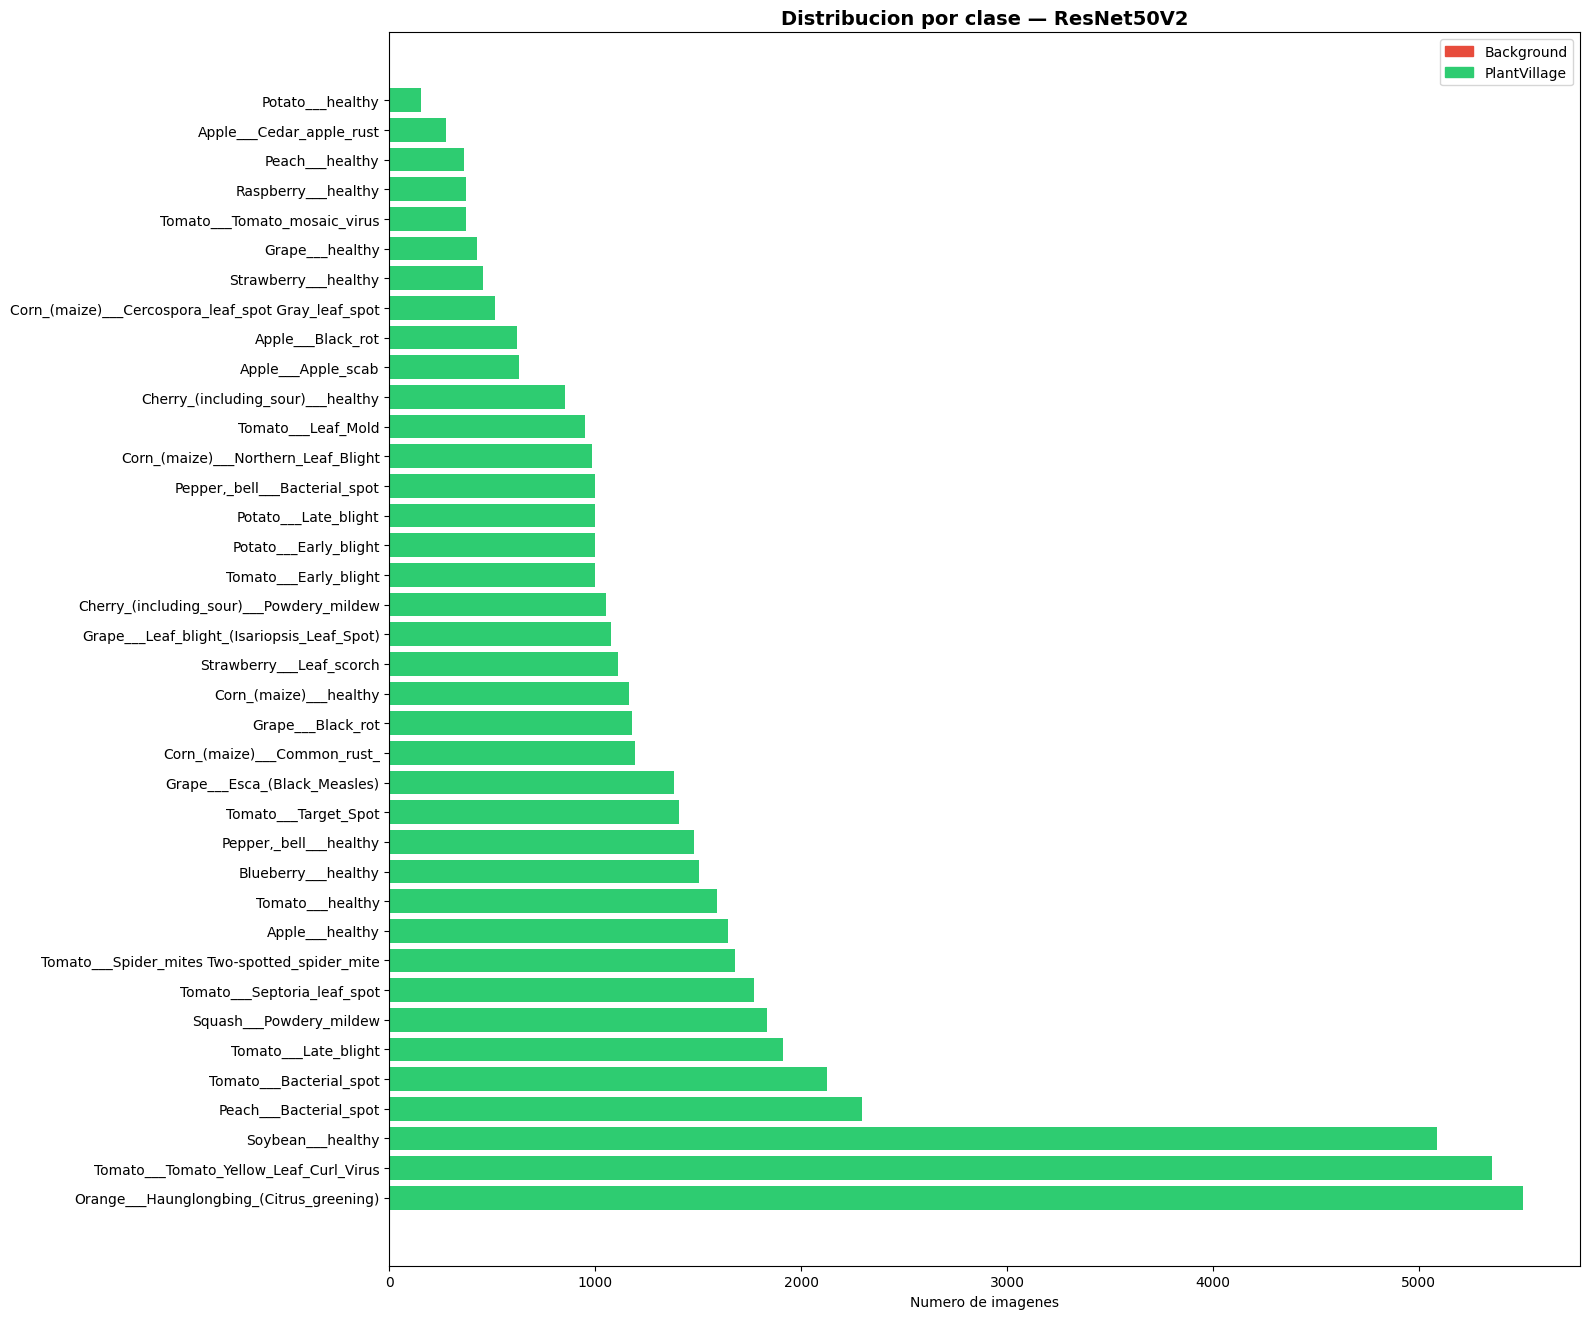

                                             Clase  Cantidad
          Orange___Haunglongbing_(Citrus_greening)      5507
            Tomato___Tomato_Yellow_Leaf_Curl_Virus      5357
                                 Soybean___healthy      5090
                            Peach___Bacterial_spot      2297
                           Tomato___Bacterial_spot      2127
                              Tomato___Late_blight      1909
                           Squash___Powdery_mildew      1835
                       Tomato___Septoria_leaf_spot      1771
     Tomato___Spider_mites Two-spotted_spider_mite      1676
                                   Apple___healthy      1645
                                  Tomato___healthy      1591
                               Blueberry___healthy      1502
                            Pepper,_bell___healthy      1478
                              Tomato___Target_Spot      1404
                      Grape___Esca_(Black_Measles)      1384
                       C

In [25]:
class_counts = {}
for class_dir in sorted(UNIFIED_DIR.iterdir()):
    if class_dir.is_dir():
        imgs = [f for f in class_dir.iterdir()
                if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]
        class_counts[class_dir.name] = len(imgs)

total = sum(class_counts.values())
print(f'Total clases  : {len(class_counts)}')
print(f'Total imagenes: {total:,}')

df_counts = pd.DataFrame(
    list(class_counts.items()), columns=['Clase', 'Cantidad']
).sort_values('Cantidad', ascending=False)

fig, ax = plt.subplots(figsize=(16, max(6, len(class_counts) * 0.35)))
colors = ['#e74c3c' if 'Background' in c else '#2ecc71' for c in df_counts['Clase']]
ax.barh(df_counts['Clase'], df_counts['Cantidad'], color=colors)
ax.set_xlabel('Numero de imagenes')
ax.set_title('Distribucion por clase — ResNet50V2', fontsize=14, fontweight='bold')
bg_patch = mpatches.Patch(color='#e74c3c', label='Background')
pv_patch = mpatches.Patch(color='#2ecc71', label='PlantVillage')
ax.legend(handles=[bg_patch, pv_patch])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()
print(df_counts.to_string(index=False))

## 6. División del dataset

In [26]:
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

def split_dataset(unified_dir, train_dir, val_dir, test_dir,
                  val_split=0.15, test_split=0.10, seed=42):
    if train_dir.exists():
        print('Split ya existe, omitiendo...')
        return

    random.seed(seed)
    for split_dir in [train_dir, val_dir, test_dir]:
        split_dir.mkdir(parents=True, exist_ok=True)

    total_copied = 0
    for class_dir in sorted(unified_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        imgs = [f for f in class_dir.iterdir()
                if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}]
        random.shuffle(imgs)

        n_test = max(1, int(len(imgs) * test_split))
        n_val  = max(1, int(len(imgs) * val_split))

        splits = {
            test_dir : imgs[:n_test],
            val_dir  : imgs[n_test:n_test + n_val],
            train_dir: imgs[n_test + n_val:]
        }

        for dest_dir, files in splits.items():
            cls_dest = dest_dir / class_dir.name
            cls_dest.mkdir(exist_ok=True)
            for f in files:
                shutil.copy2(str(f), str(cls_dest / f.name))
                total_copied += 1

    print(f'Split completado: {total_copied:,} imagenes distribuidas')
    for name, d in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
        n = sum(1 for f in d.rglob('*') if f.is_file())
        print(f'  {name}: {n:,}')


split_dataset(UNIFIED_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR,
              val_split=VAL_SPLIT, test_split=TEST_SPLIT)

Split ya existe, omitiendo...


## 7. Pipelines tf.data (más eficiente que ImageDataGenerator)

In [27]:
# Detectar clases desde el directorio de entrenamiento
CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

with open(CLASS_NAMES_PATH, 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

print(f'Clases detectadas : {NUM_CLASSES}')
print(f'Clases guardadas en: {CLASS_NAMES_PATH}')


def make_dataset(directory, training=False, batch_size=BATCH_SIZE):
    """
    Pipeline tf.data con prefetch y augmentation on-GPU.
    Más rápido que ImageDataGenerator al aprovechar XLA y tf.function.
    """
    # Recopilar todas las rutas e índices de clase
    all_paths, all_labels = [], []
    for cls in CLASS_NAMES:
        cls_dir = Path(directory) / cls
        if not cls_dir.exists():
            continue
        for img_path in cls_dir.iterdir():
            if img_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
                all_paths.append(str(img_path))
                all_labels.append(class_to_idx[cls])

    ds = tf.data.Dataset.from_tensor_slices((all_paths, all_labels))

    if training:
        ds = ds.shuffle(buffer_size=len(all_paths), seed=SEED)

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_input(img)  # ResNet50V2: escala a [-1, 1]
        label_oh = tf.one_hot(label, NUM_CLASSES)
        return img, label_oh

    def augment(img, label):
        # IMPORTANTE: solo operaciones tf.image puras.
        # NO usar tf.keras.layers.RandomRotation/Zoom aquí —
        # crean tf.Variables dentro de tf.function y lanzan ValueError.
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        # Zoom simulado: recorte aleatorio + resize (equivale a zoom-in)
        scale = tf.random.uniform([], 0.80, 1.0)
        crop_h = tf.cast(tf.cast(IMG_SIZE, tf.float32) * scale, tf.int32)
        img = tf.image.random_crop(img, size=[crop_h, crop_h, 3])
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        return img, label

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # ← GPU nunca espera a CPU
    return ds, len(all_paths)


train_ds, n_train = make_dataset(TRAIN_DIR, training=True)
val_ds,   n_val   = make_dataset(VAL_DIR,   training=False)
test_ds,  n_test  = make_dataset(TEST_DIR,  training=False)

print(f'\nTrain  : {n_train:,} imágenes')
print(f'Val    : {n_val:,} imágenes')
print(f'Test   : {n_test:,} imágenes')

Clases detectadas : 38
Clases guardadas en: /kaggle/working/class_names.json

Train  : 40,760 imágenes
Val    : 8,129 imágenes
Test   : 5,417 imágenes


## 8. Construcción del modelo ResNet50V2

In [28]:
def build_resnet50v2(num_classes, input_shape=(224, 224, 3), freeze_backbone=True):
    """
    ResNet50V2 preentrenado en ImageNet con cabeza personalizada.

    ResNet50V2 vs MobileNetV2:
      - ~25M parámetros (más potente en tareas complejas)
      - Mayor capacidad de representación → mejor accuracy en PlantVillage
      - La versión V2 usa pre-activación (BN → ReLU antes de convolución)
        lo que mejora el flujo de gradientes y la convergencia
    
    Cabeza:
      GlobalAveragePooling2D → Dense(512) → BN → ReLU → Dropout(0.4)
                             → Dense(256) → BN → ReLU → Dropout(0.3)
                             → Dense(num_classes, softmax)
    """
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = not freeze_backbone

    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    # dtype=float32 explícito para estabilidad con mixed_precision
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = keras.Model(inputs, outputs)
    return model, base_model


model, base_model = build_resnet50v2(NUM_CLASSES, freeze_backbone=True)

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'Parametros totales     : {total_params:,}')
print(f'Parametros entrenables : {trainable_params:,}  (solo cabeza en Fase 1)')
model.summary()

Parametros totales     : 24,758,054
Parametros entrenables : 1,191,718  (solo cabeza en Fase 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,758,054 (94.44 MB)

 Trainable params: 1,191,718 (4.55 MB)

 Non-trainable params: 23,566,336 (89.90 MB)

## 9. Callbacks

In [29]:
def make_callbacks(model_path, append_csv=False):
    checkpoint = callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor='val_accuracy',   # ResNet50V2 suele ser más estable en accuracy
        save_best_only=True,
        save_weights_only=False,
        mode='max',
        verbose=1
    )
    early_stop = callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=ES_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=LR_PATIENCE,
        min_lr=1e-8,
        mode='max',
        verbose=1
    )
    csv_logger = callbacks.CSVLogger(
        str(OUTPUT_DIR / 'training_log.csv'), append=append_csv
    )
    return [checkpoint, early_stop, reduce_lr, csv_logger]


print('Callbacks configurados:')
print(f'  ModelCheckpoint   → guarda mejor modelo (val_accuracy)')
print(f'  EarlyStopping     → patience={ES_PATIENCE} epocas')
print(f'  ReduceLROnPlateau → patience={LR_PATIENCE} epocas, factor=0.3')
print(f'  CSVLogger         → registra historial en training_log.csv')

Callbacks configurados:
  ModelCheckpoint   → guarda mejor modelo (val_accuracy)
  EarlyStopping     → patience=5 epocas
  ReduceLROnPlateau → patience=3 epocas, factor=0.3
  CSVLogger         → registra historial en training_log.csv


## 10. Entrenamiento — Fase 1 (solo cabeza)

In [30]:
print('=' * 60)
print('FASE 1: Entrenando solo la cabeza (backbone congelado)')
print(f'        {PHASE1_EPOCHS} épocas máx — convergencia rápida')
print('=' * 60)

history1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=make_callbacks(BEST_MODEL_PATH, append_csv=False)
)

print(f'\nFase 1 completada.')
print(f'Mejor val_accuracy: {max(history1.history["val_accuracy"]):.4f}')

FASE 1: Entrenando solo la cabeza (backbone congelado)
        10 épocas máx — convergencia rápida
Epoch 1/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5202 - loss: 1.8636
Epoch 1: val_accuracy improved from -inf to 0.78263, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.5204 - loss: 1.8627 - val_accuracy: 0.7826 - val_loss: 0.7108 - learning_rate: 3.0000e-04
Epoch 2/10
636/637 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7952 - loss: 0.6811
Epoch 2: val_accuracy improved from 0.78263 to 0.82852, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7952 - loss: 0.6810 - val_accuracy: 0.8285 - val_loss: 0.5317 - learning_rate: 3.0000e-04
Epoch 3/10
636/637 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8330 - loss: 0.5265
Epoch 3: val_accuracy improved from 0.82852 to 0.84943, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.8330 - loss: 0.5265 - val_accuracy: 0.8494 - val_loss: 0.4687 - learning_rate: 3.0000e-04
Epoch 4/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8549 - loss: 0.4625
Epoch 4: val_accuracy improved from 0.84943 to 0.85115, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8549 - loss: 0.4625 - val_accuracy: 0.8512 - val_loss: 0.4463 - learning_rate: 3.0000e-04
Epoch 5/10
636/637 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8621 - loss: 0.4222
Epoch 5: val_accuracy improved from 0.85115 to 0.87009, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8621 - loss: 0.4222 - val_accuracy: 0.8701 - val_loss: 0.3863 - learning_rate: 3.0000e-04
Epoch 6/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8686 - loss: 0.4028
Epoch 6: val_accuracy did not improve from 0.87009
637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.8686 - loss: 0.4028 - val_accuracy: 0.8681 - val_loss: 0.3884 - learning_rate: 3.0000e-04
Epoch 7/10
636/637 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8796 - loss: 0.3721
Epoch 7: val_accuracy did not improve from 0.87009
637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.8796 - loss: 0.3721 - val_accuracy: 0.8614 - val_loss: 0.4105 - learning_rate: 3.0000e-04
Epoch 8/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8811 - loss: 0.3588
Epoch 8: val_accuracy did not improve from 0.87009

Epoch 8: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8811 - loss

637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.8906 - loss: 0.3335 - val_accuracy: 0.8885 - val_loss: 0.3405 - learning_rate: 9.0000e-05
Epoch 10/10
636/637 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8937 - loss: 0.3190
Epoch 10: val_accuracy did not improve from 0.88855
637/637 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.8937 - loss: 0.3189 - val_accuracy: 0.8815 - val_loss: 0.3581 - learning_rate: 9.0000e-05
Restoring model weights from the end of the best epoch: 9.

Fase 1 completada.
Mejor val_accuracy: 0.8885


## 11. Entrenamiento — Fase 2 (fine-tune)

In [31]:
print('=' * 60)
print('FASE 2: Fine-tune (descongelando últimas capas de ResNet50V2)')
print(f'        Capas congeladas: primeras {UNFREEZE_LAYER}')
print(f'        Épocas máx: {PHASE2_EPOCHS}  (EarlyStopping patience={ES_PATIENCE})')
print('=' * 60)

# ResNet50V2 tiene ~190 capas; descongelamos las últimas ~50
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_LAYER]:
    layer.trainable = False

trainable_p2 = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f'\nParámetros entrenables fase 2: {trainable_p2:,}')

# LR 10× menor para no destruir pesos pre-entrenados
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LR / 10, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=make_callbacks(BEST_MODEL_PATH, append_csv=True)
)

print(f'\nFase 2 completada.')
print(f'Mejor val_accuracy: {max(history2.history["val_accuracy"]):.4f}')

FASE 2: Fine-tune (descongelando últimas capas de ResNet50V2)
        Capas congeladas: primeras 140
        Épocas máx: 20  (EarlyStopping patience=5)

Parámetros entrenables fase 2: 17,543,974
Epoch 1/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8348 - loss: 0.5147
Epoch 1: val_accuracy improved from -inf to 0.90884, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 107s 119ms/step - accuracy: 0.8349 - loss: 0.5145 - val_accuracy: 0.9088 - val_loss: 0.2637 - learning_rate: 3.0000e-05
Epoch 2/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9159 - loss: 0.2545
Epoch 2: val_accuracy improved from 0.90884 to 0.92262, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9159 - loss: 0.2545 - val_accuracy: 0.9226 - val_loss: 0.2286 - learning_rate: 3.0000e-05
Epoch 3/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9356 - loss: 0.1922
Epoch 3: val_accuracy improved from 0.92262 to 0.92398, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9356 - loss: 0.1922 - val_accuracy: 0.9240 - val_loss: 0.2286 - learning_rate: 3.0000e-05
Epoch 4/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9496 - loss: 0.1574
Epoch 4: val_accuracy improved from 0.92398 to 0.93492, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9496 - loss: 0.1574 - val_accuracy: 0.9349 - val_loss: 0.1942 - learning_rate: 3.0000e-05
Epoch 5/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9517 - loss: 0.1443
Epoch 5: val_accuracy did not improve from 0.93492
637/637 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step - accuracy: 0.9517 - loss: 0.1443 - val_accuracy: 0.9294 - val_loss: 0.2070 - learning_rate: 3.0000e-05
Epoch 6/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9607 - loss: 0.1191
Epoch 6: val_accuracy improved from 0.93492 to 0.94464, saving model to /kaggle/working/resnet50v2_best_model.h5


...

637/637 ━━━━━━━━━━━━━━━━━━━━ 53s 83ms/step - accuracy: 0.9739 - loss: 0.0812 - val_accuracy: 0.9492 - val_loss: 0.1621 - learning_rate: 3.0000e-05
Epoch 10/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9760 - loss: 0.0784
Epoch 10: val_accuracy improved from 0.94919 to 0.96174, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 53s 83ms/step - accuracy: 0.9760 - loss: 0.0784 - val_accuracy: 0.9617 - val_loss: 0.1234 - learning_rate: 3.0000e-05
Epoch 11/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9766 - loss: 0.0730
Epoch 11: val_accuracy did not improve from 0.96174
637/637 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - accuracy: 0.9766 - loss: 0.0730 - val_accuracy: 0.9525 - val_loss: 0.1491 - learning_rate: 3.0000e-05
Epoch 12/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9799 - loss: 0.0651
Epoch 12: val_accuracy did not improve from 0.96174
637/637 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - accuracy: 0.9799 - loss: 0.0651 - val_accuracy: 0.9598 - val_loss: 0.1193 - learning_rate: 3.0000e-05
Epoch 13/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9810 - loss: 0.0598
Epoch 13: val_accuracy did not improve from 0.96174

Epoch 13: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
637/637 ━━━━━━━━━━━━━━━━━━━━ 52s 81ms/step - accuracy: 0.9810

637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9872 - loss: 0.0420 - val_accuracy: 0.9632 - val_loss: 0.1144 - learning_rate: 9.0000e-06
Epoch 16/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9882 - loss: 0.0389
Epoch 16: val_accuracy improved from 0.96322 to 0.96740, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9882 - loss: 0.0389 - val_accuracy: 0.9674 - val_loss: 0.1039 - learning_rate: 9.0000e-06
Epoch 17/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9886 - loss: 0.0374
Epoch 17: val_accuracy did not improve from 0.96740
637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9886 - loss: 0.0374 - val_accuracy: 0.9636 - val_loss: 0.1104 - learning_rate: 9.0000e-06
Epoch 18/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9900 - loss: 0.0349
Epoch 18: val_accuracy improved from 0.96740 to 0.96752, saving model to /kaggle/working/resnet50v2_best_model.h5


637/637 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.9900 - loss: 0.0349 - val_accuracy: 0.9675 - val_loss: 0.0997 - learning_rate: 9.0000e-06
Epoch 19/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9908 - loss: 0.0328
Epoch 19: val_accuracy did not improve from 0.96752
637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 85ms/step - accuracy: 0.9908 - loss: 0.0328 - val_accuracy: 0.9636 - val_loss: 0.1147 - learning_rate: 9.0000e-06
Epoch 20/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9895 - loss: 0.0349
Epoch 20: val_accuracy did not improve from 0.96752
637/637 ━━━━━━━━━━━━━━━━━━━━ 54s 84ms/step - accuracy: 0.9895 - loss: 0.0349 - val_accuracy: 0.9637 - val_loss: 0.1101 - learning_rate: 9.0000e-06
Restoring model weights from the end of the best epoch: 18.

Fase 2 completada.
Mejor val_accuracy: 0.9675


## 12. Curvas de aprendizaje

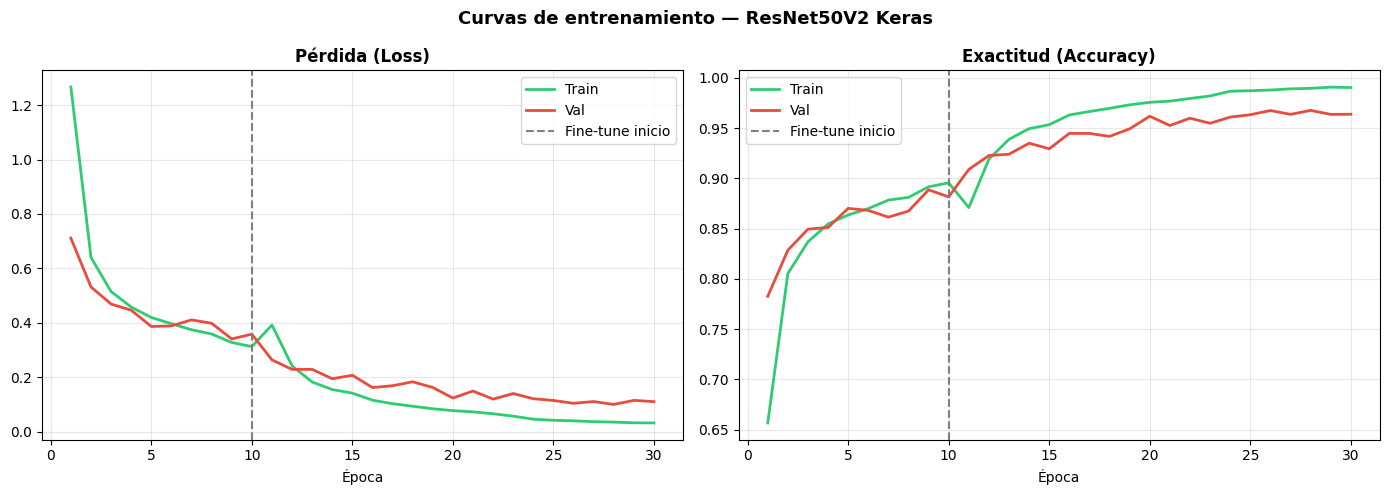

In [32]:
train_loss = history1.history['loss'] + history2.history['loss']
val_loss   = history1.history['val_loss'] + history2.history['val_loss']
train_acc  = history1.history['accuracy'] + history2.history['accuracy']
val_acc    = history1.history['val_accuracy'] + history2.history['val_accuracy']
epochs_ran = list(range(1, len(train_loss) + 1))
ft_start   = len(history1.history['loss'])  # época donde comenzó el fine-tune

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, train_loss, label='Train', linewidth=2, color='#2ecc71')
axes[0].plot(epochs_ran, val_loss,   label='Val',   linewidth=2, color='#e74c3c')
axes[0].axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tune inicio')
axes[0].set_title('Pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, train_acc, label='Train', linewidth=2, color='#2ecc71')
axes[1].plot(epochs_ran, val_acc,   label='Val',   linewidth=2, color='#e74c3c')
axes[1].axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tune inicio')
axes[1].set_title('Exactitud (Accuracy)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de entrenamiento — ResNet50V2 Keras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'learning_curves.png', dpi=120)
plt.show()

## 13. Evaluación en Test Set

In [33]:
best_model = keras.models.load_model(BEST_MODEL_PATH)
print(f'Mejor modelo cargado desde: {BEST_MODEL_PATH}')

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

# Reconstruir predicciones manteniendo el orden correcto
all_preds, all_labels = [], []
for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(np.argmax(labels.numpy(), axis=1))

pred_classes = np.array(all_preds)
true_classes = np.array(all_labels)

print('\nReporte de clasificacion:')
print(classification_report(true_classes, pred_classes,
                             target_names=CLASS_NAMES, digits=4))

Mejor modelo cargado desde: /kaggle/working/resnet50v2_best_model.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 126ms/step - accuracy: 0.9737 - loss: 0.0853

Test Loss     : 0.1042
Test Accuracy : 0.9673 (96.73%)

Reporte de clasificacion:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.8254    0.9043        63
                                 Apple___Black_rot     1.0000    1.0000    1.0000        62
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        27
                                   Apple___healthy     0.9318    1.0000    0.9647       164
                               Blueberry___healthy     0.9934    1.0000    0.9967       150
          Cherry_(including_sour)___Powdery_mildew     0.9905    0.9905    0.9905       105
                 Cherry_(including_sour)___healthy     1.0000    0.9882    0.9941        85
Corn_(maize)___Cercospora_leaf_spot

## 14. Matriz de confusión

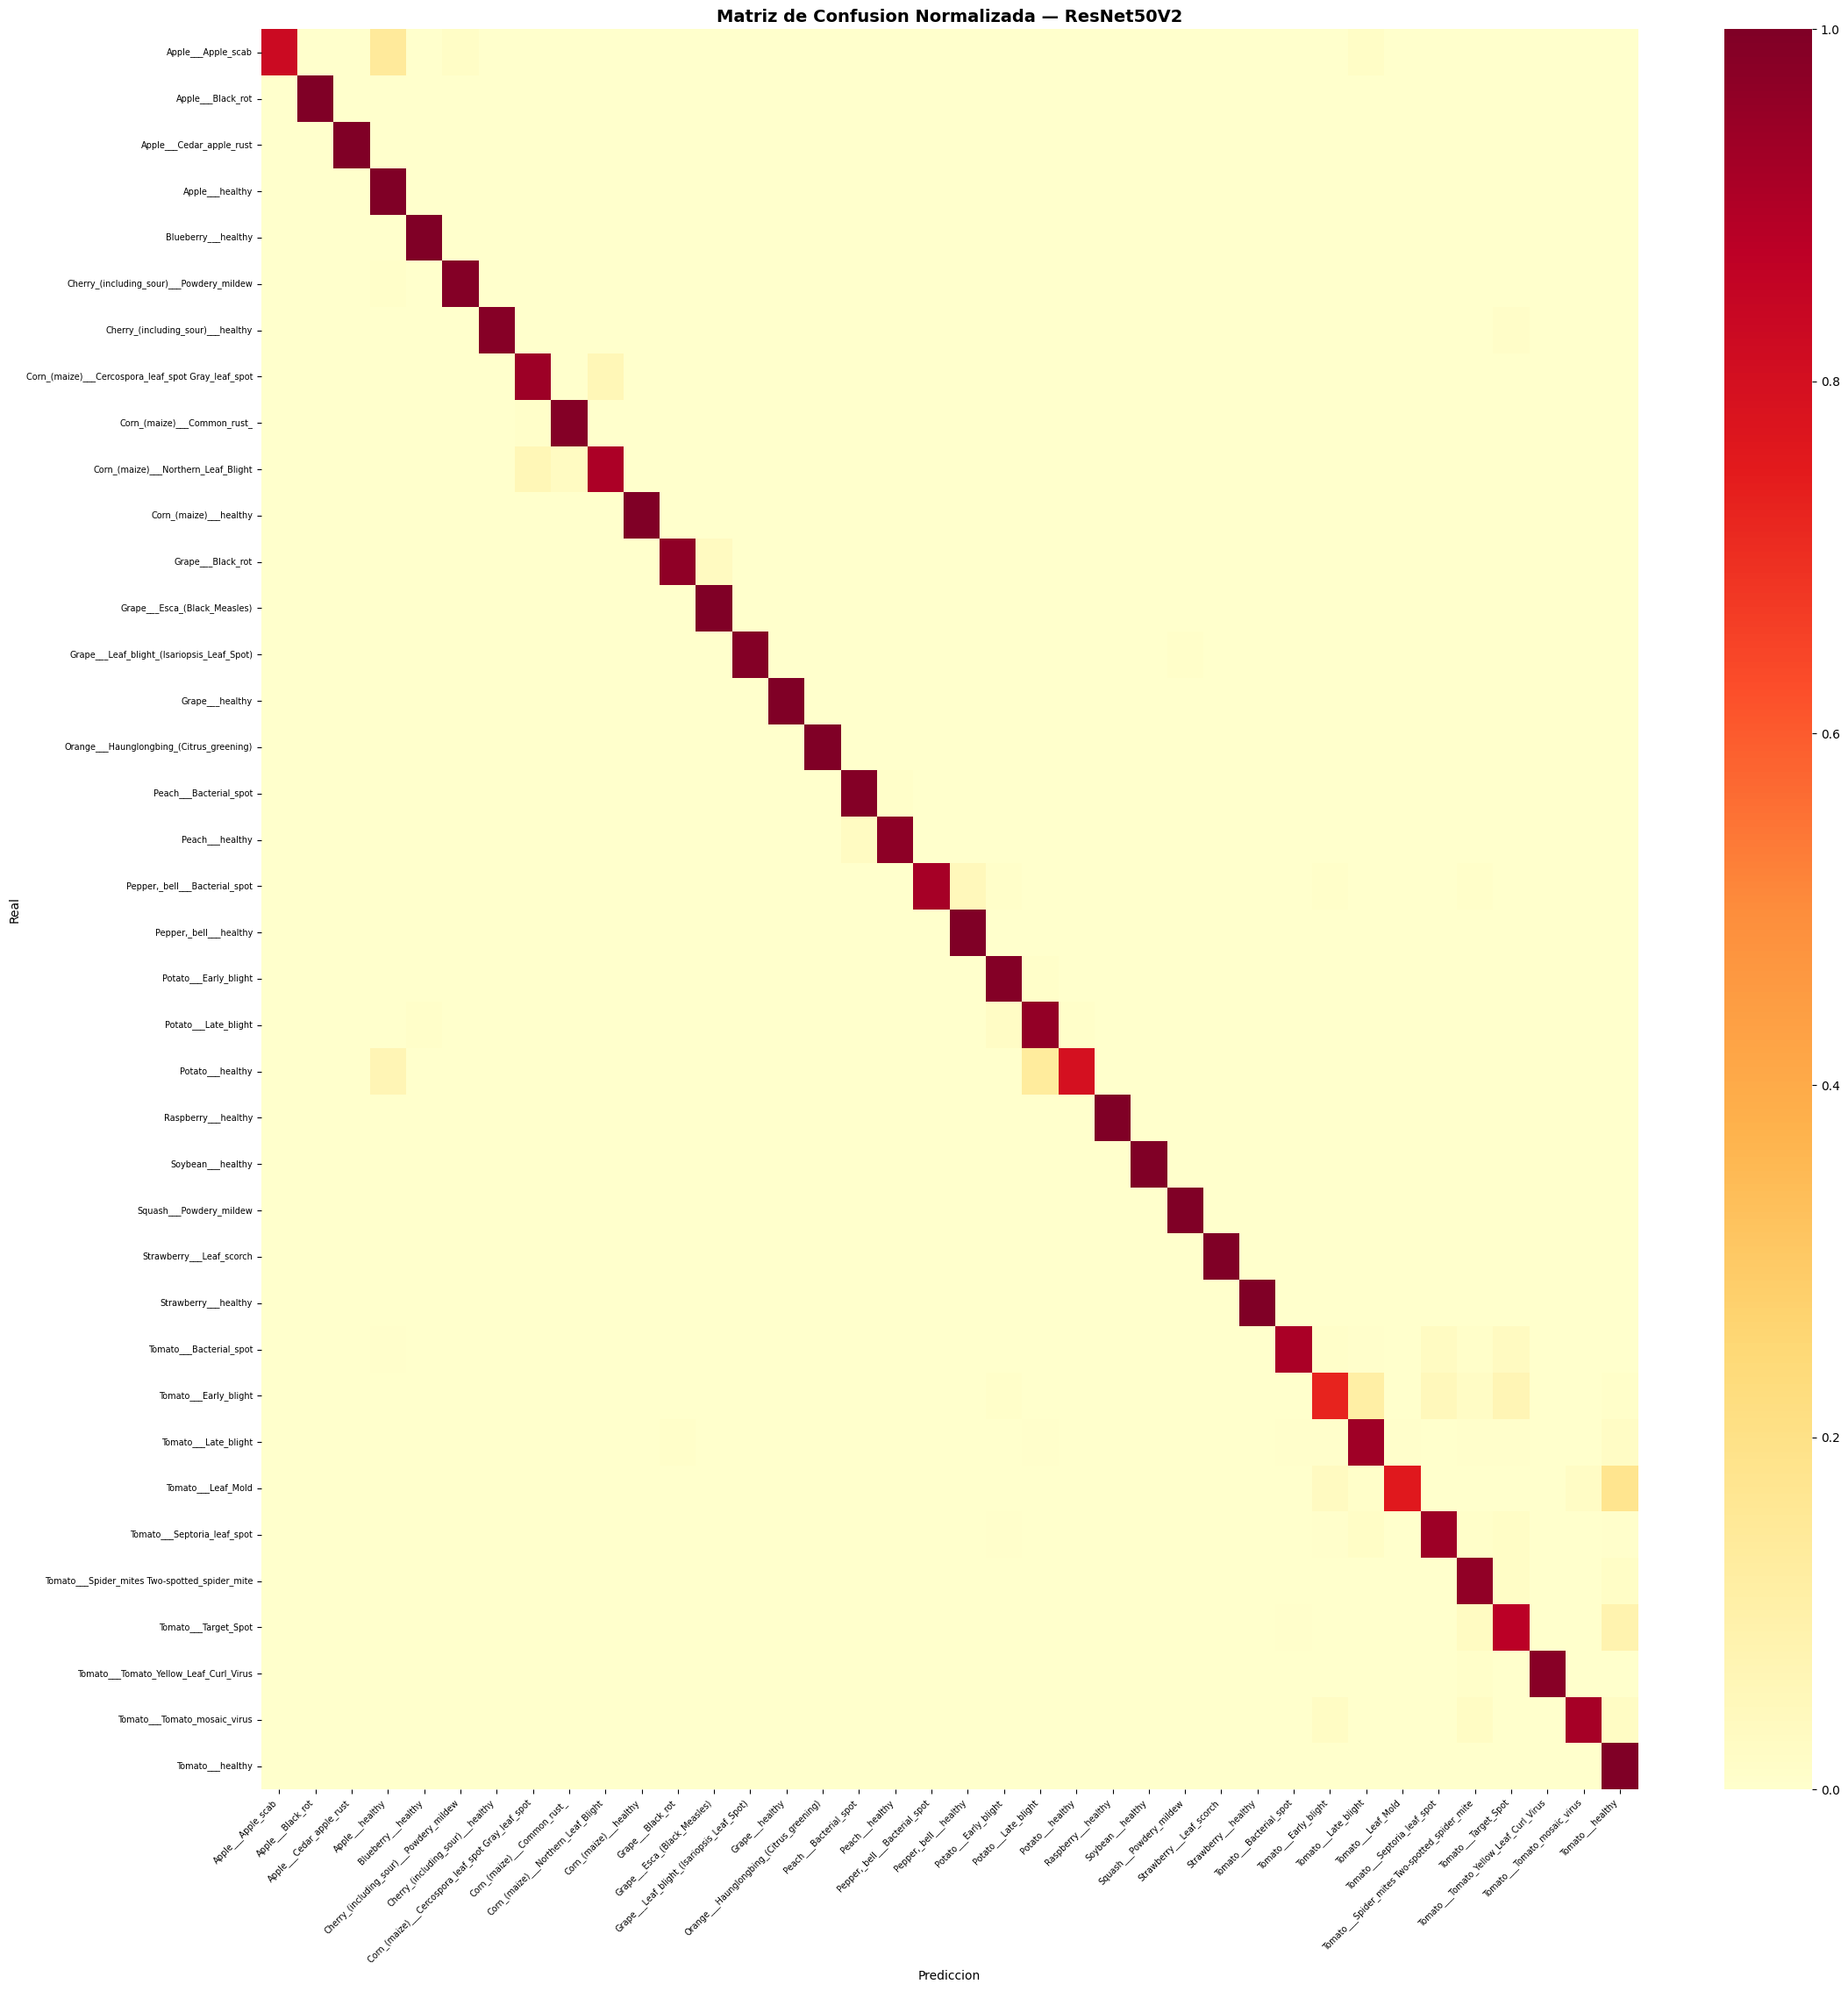

In [34]:
cm = confusion_matrix(true_classes, pred_classes)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig_size = max(16, NUM_CLASSES * 0.6)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
sns.heatmap(cm_norm, annot=NUM_CLASSES <= 30, fmt='.2f',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cmap='YlOrRd', ax=ax)
ax.set_title('Matriz de Confusion Normalizada — ResNet50V2', fontsize=14, fontweight='bold')
ax.set_ylabel('Real')
ax.set_xlabel('Prediccion')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

if 'Background' in CLASS_NAMES:
    bg_idx  = CLASS_NAMES.index('Background')
    bg_mask = true_classes == bg_idx
    bg_acc  = (pred_classes[bg_mask] == bg_idx).mean() if bg_mask.any() else 0
    false_bg = ((true_classes != bg_idx) & (pred_classes == bg_idx)).sum()
    print(f'Background recall    : {bg_acc:.4f}')
    print(f'Plantas como fondo   : {false_bg}')

## 15. Guardar modelo final y exportar a TFLite

In [ ]:
# ── Guardar modelo final en .h5 ───────────────────────────────────────────────
best_model.save(FINAL_MODEL_PATH)
print(f'Modelo final guardado  : {FINAL_MODEL_PATH}')
print(f'Mejor modelo guardado  : {BEST_MODEL_PATH}')

# ── Exportar a TFLite (cuantización de pesos, sin calibración → rápido) ───────
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# SIN representative_dataset → solo cuantiza pesos (segundos, no minutos)
# Si quieres INT8 completo después, puedes correrlo aparte con take(3)

try:
    tflite_model = converter.convert()
    tflite_path = OUTPUT_DIR / 'resnet50v2_android.tflite'
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    tflite_size = os.path.getsize(tflite_path) / 1e6
    print(f'  resnet50v2_android.tflite : {tflite_size:.1f} MB')
except Exception as e:
    print(f'TFLite falló: {e}')
    tflite_size = 0

h5_size = os.path.getsize(BEST_MODEL_PATH) / 1e6
print(f'\nArchivos generados:')
print(f'  resnet50v2_best_model.h5  : {h5_size:.1f} MB')
print(f'  resnet50v2_android.tflite : {tflite_size:.1f} MB  ← usar en Android')
print(f'  class_names.json          : lista de clases')
print(f'  learning_curves.png       : curvas de entrenamiento')
print(f'  confusion_matrix.png      : matriz de confusion')

Modelo final guardado  : /kaggle/working/resnet50v2_final_model.h5
Mejor modelo guardado  : /kaggle/working/resnet50v2_best_model.h5
INFO:tensorflow:Assets written to: /tmp/tmpy5mxtmre/assets


INFO:tensorflow:Assets written to: /tmp/tmpy5mxtmre/assets


Saved artifact at '/tmp/tmpy5mxtmre'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  134404268239056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268238864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268239440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268240208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268240016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268237712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268239824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268235792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268238096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268238288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134404268240

## 16. Función de inferencia con el .h5

In [ ]:
def predict_image(img_path, model_path, class_names_path, img_size=224, top_k=3):
    """
    Predicción sobre una imagen nueva usando ResNet50V2.

    Uso:
        results = predict_image('hoja.jpg', 'resnet50v2_best_model.h5', 'class_names.json')
        for r in results: print(r['class'], r['confidence'])
    """
    from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

    model = keras.models.load_model(model_path)
    with open(class_names_path) as f:
        class_names = json.load(f)

    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    arr = np.array(img, dtype=np.float32)
    arr = resnet_preprocess(arr)          # escala a [-1, 1]
    arr = np.expand_dims(arr, axis=0)

    probs    = model.predict(arr, verbose=0)[0]
    top_idxs = np.argsort(probs)[::-1][:top_k]

    return [
        {'class': class_names[i], 'confidence': float(probs[i])}
        for i in top_idxs
    ]


# Prueba rápida con una imagen del test set
sample_path = next(TEST_DIR.rglob('*.jpg'), None) or next(TEST_DIR.rglob('*.png'), None)
if sample_path:
    results = predict_image(
        str(sample_path), BEST_MODEL_PATH, str(CLASS_NAMES_PATH)
    )
    print('Prediccion de prueba:')
    for r in results:
        print(f"  {r['class']:40s} {r['confidence']:.4f}")
else:
    print('No se encontró imagen de prueba')

## 17. Resumen de archivos generados

| Archivo | Descripción | Uso |
|---|---|---|
| `resnet50v2_best_model.h5` | Mejor modelo completo Keras | Inferencia en Python |
| `resnet50v2_final_model.h5` | Modelo al terminar | Backup |
| `resnet50v2_android.tflite` | Modelo INT8 cuantizado | **Android / iOS** |
| `class_names.json` | Lista de clases en orden | Requerido para inferencia |
| `training_log.csv` | Historial de métricas | Análisis posterior |
| `learning_curves.png` | Gráficas de entrenamiento | Visualización |
| `confusion_matrix.png` | Matriz de confusión | Evaluación |

**Para cargar el modelo en otro notebook:**
```python
from tensorflow import keras
model = keras.models.load_model('resnet50v2_best_model.h5')
```

**Diferencias clave vs MobileNetV2:**
- ResNet50V2 usa ~25M parámetros vs ~3.4M de MobileNetV2 → mayor capacidad
- La versión V2 (pre-activación) converge más estable y rápido que ResNet50 clásica
- `tf.data` con prefetch + `mixed_float16` compensan el mayor tamaño del modelo
- El `.tflite` INT8 cuantizado reduce el modelo ~4× para uso en Android
- EarlyStopping patience=5 garantiza no desperdiciar GPU si ya convergió

**Estimación de tiempo en Kaggle T4:**
- Fase 1 (5 épocas): ~10–15 min
- Fase 2 (≤15 épocas, EarlyStopping): ~60–100 min
- Evaluación + TFLite: ~10 min
- **Total estimado: ~80–125 min → bien dentro de las 3h**